# EDA: Age Restrictions, Bedrooms, Documentation & City Heatmap

This notebook performs exploratory data analysis on `Combined_ResaleSept25_NewEntries.csv`.

Visualizations (Matplotlib / Seaborn):

- Age restricted (55+, 62+, none) and cities (geocoded heatmap if geocoding available)
- Age restricted vs bedroom size
- Age restricted vs documentation type

Notes:
- The notebook *includes* geocoding code using `geopy` (Nominatim). That requires internet access when you run the notebook. If geocoding is unavailable, the notebook will fall back to a city count bar chart and a jittered scatter 'heatmap' representation.

In [ ]:

# Imports and plotting settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set(style='whitegrid')
%matplotlib inline

DATA_PATH = Path('/content/Combined_ResaleSept25_NewEntries.csv')
print('Data path exists?', DATA_PATH.exists())


Data path exists? True


In [ ]:

# Load the CSV
df = pd.read_csv(DATA_PATH)
print('Data shape:', df.shape)
df_columns = df.columns.tolist()
print('Columns:', df_columns)
df.head().astype(str)


Data shape: (166, 19)
Columns: ['Town', 'Development', 'Unit Number', 'Address', 'Transaction Start Date', 'Closing Date', 'Bedrooms', 'Age Restricted', 'Full/Lite Documentation', 'Duplicate', 'Unique ID', 'Street Address', 'City', 'State', 'ZIP', 'Match Status', 'Match Type', 'Matched Address', 'MSA']


,Town,Development,Unit Number,Address,Transaction Start Date,Closing Date,Bedrooms,Age Restricted,Full/Lite Documentation,Duplicate,Unique ID,Street Address,City,State,ZIP,Match Status,Match Type,Matched Address,MSA
0,Pembroke,Barker Square,23,7 Barker Square Drive,1/31/21,9/30/22,2,55+,Full,False,116.0,7 Barker Square Drive,Pembroke,MA,nan,Match,Exact,"7 BARKER SQUARE DR, PEMBROKE, MA, 02359","BOSTON-CAMBRIDGE-NEWTON, MA-NH"
1,Great Barrington,Blue Hill Commons,nan,6 Emily Court,3/11/21,7/7/21,3,No,Full,False,41.0,6 Emily Court,Great Barrington,MA,nan,Match,Exact,"6 EMILY CT, GREAT BARRINGTON, MA, 01230","PITTSFIELD, MA"
2,Taunton,Powhattan Estates,nan,65 Metacomet Avenue,5/17/21,9/17/21,3,No,Full,False,134.0,65 Metacomet Avenue,Taunton,MA,nan,Match,Non_Exact,"65 METACOMET AVE, EAST TAUNTON, MA, 02718","PROVIDENCE-WARWICK, RI-MA"
3,Bedford,The Village at Bedford Woods,1301,1301 Albion Road,5/19/21,8/16/21,2,No,Full,True,10.0,1301 Albion Road,Bedford,MA,nan,Match,Exact,"1301 ALBION RD, BEDFORD, MA, 01730","BOSTON-CAMBRIDGE-NEWTON, MA-NH"
4,Billerica,Barrett Farm,233,41 Boston Road,7/12/21,10/28/21,2,No,Full,False,14.0,41 Boston Road,Billerica,MA,nan,Match,Non_Exact,"41 BOSTON RD, N BILLERICA, MA, 01862","BOSTON-CAMBRIDGE-NEWTON, MA-NH"


In [ ]:

# Clean and standardize 'Age Restricted' column
age_col_candidates = [c for c in df.columns if 'Age Restricted' in c or c.lower().strip()=='age restricted']
age_col = age_col_candidates[0] if age_col_candidates else None
age_col


'Age Restricted'

In [ ]:

if age_col is None:
    raise ValueError("Couldn't find an 'Age Restricted' column automatically. Please update the column name in the notebook. Columns available:\n" + "\n".join(df.columns))
else:
    df['age_restricted_raw'] = df[age_col].astype(str).str.strip()

# Normalize categories to '55+', '62+', 'No' (or 'None')
def normalize_age(x):
    if pd.isna(x):
        return 'No'
    s = str(x).strip().lower()
    if '55' in s:
        return '55+'
    if '62' in s:
        return '62+'
    if s in ['no', 'none', 'n/a', 'na', '', 'no ']:
        return 'No'
    return s.title()

df['age_restricted'] = df['age_restricted_raw'].apply(normalize_age)
df['age_restricted'].value_counts(dropna=False)


,count
age_restricted,
No,109
55+,44
Nan,7
62+,6


In [ ]:

# Detect city column (prefer 'City' or 'Town' columns)
city_col = None
for cand in ['City', 'Town', 'Town/City', 'city', 'town']:
    if cand in df.columns:
        city_col = cand
        break
if city_col is None:
    # fallback: try to find a column with many repeats that looks like city names
    potential = [c for c in df.columns if df[c].nunique() < (len(df) * 0.5)]
    city_col = potential[0] if potential else df.columns[0]
print('Using city column:', city_col)
df['city_for_geo'] = df[city_col].astype(str).str.title().str.strip()
df['city_for_geo'].value_counts().head()


Using city column: City


,count
city_for_geo,
North Andover,15
Nan,8
Hudson,8
Sturbridge,7
Methuen,5


In [ ]:

# City-level counts by age restriction
city_age_counts = (df.groupby(['city_for_geo', 'age_restricted'])
                     .size()
                     .reset_index(name='count'))
city_totals = df['city_for_geo'].value_counts().reset_index()
city_totals.columns = ['city_for_geo', 'total_count']
city_summary = city_totals.merge(city_age_counts, on='city_for_geo', how='left')
city_summary.head()


,city_for_geo,total_count,age_restricted,count
0,North Andover,15,55+,5
1,North Andover,15,No,10
2,Nan,8,55+,1
3,Nan,8,Nan,7
4,Hudson,8,55+,7


## Geocoding cities

This cell attempts to geocode each unique city using `geopy`'s Nominatim service. **This requires internet access** when you run the notebook. Results will be cached to `city_coords_cache.csv` in the working directory. If geocoding fails or you prefer not to geocode, skip this cell and the notebook will fall back to a non-geographic heatmap alternative.

In [ ]:

# Attempt to geocode unique cities. This requires internet access!
from time import sleep
coords_cache_path = Path('city_coords_cache.csv')

def geocode_cities(df_cities, force_refresh=False):
    try:
        from geopy.geocoders import Nominatim
        from geopy.extra.rate_limiter import RateLimiter
    except Exception as e:
        print('Geopy not available in this environment:', e)
        return None

    cities = sorted(df_cities['city_for_geo'].unique())
    if coords_cache_path.exists() and not force_refresh:
        cache = pd.read_csv(coords_cache_path)
        print('Loaded cached coordinates for', len(cache), 'cities from', coords_cache_path)
    else:
        geolocator = Nominatim(user_agent='eda_age_restrict_notebook/1.0')
        geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, max_retries=2, error_wait_seconds=2.0)
        rows = []
        for c in cities:
            if c in [None, 'nan', 'None', '']:
                continue
            try:
                loc = geocode(f"{c}, MA, USA")  # limit to MA for better matching
            except Exception as e:
                print('Geocoding error for', c, ':', e)
                loc = None
            if loc:
                rows.append({'city_for_geo': c, 'lat': loc.latitude, 'lon': loc.longitude})
                print('Geocoded', c, loc.latitude, loc.longitude)
            else:
                rows.append({'city_for_geo': c, 'lat': np.nan, 'lon': np.nan})
            sleep(1.0)
        cache = pd.DataFrame(rows)
        cache.to_csv(coords_cache_path, index=False)
        print('Saved cache to', coords_cache_path)
    return cache

city_coords = None
try:
    city_coords = geocode_cities(df[['city_for_geo']])
except Exception as e:
    print('Geocoding attempt failed:', e)

city_coords.head() if (city_coords is not None and not city_coords.empty) else None


Geocoded Andover 42.65717 -71.1408776
Geocoded Ayer 42.5595807 -71.5882561
Geocoded Bedford 42.4917301 -71.2817947
Geocoded Berkley 41.8459347 -71.0828222
Geocoded Billerica 42.5584264 -71.268947
Geocoded Braintree 42.2205956 -71.0041229
Geocoded Bridgewater 41.9902206 -70.9754432
Geocoded Canton 42.1584324 -71.1447732
Geocoded Carlisle 42.5292605 -71.3495035
Geocoded Dracut 42.6688173 -71.3033665
Geocoded Easthampton 42.2708804 -72.6719579


Geocoded Edgartown 41.3894198 -70.5129682
Geocoded Falmouth 41.5514979 -70.6147519
Geocoded Foxborough 42.0653768 -71.2478308
Geocoded Grafton 42.2063399 -71.6853877
Geocoded Great Barrington 42.1939364 -73.362773
Geocoded Groton 42.6112242 -71.5745402
Geocoded Groveland 42.7598804 -71.0318212
Geocoded Hamilton 42.6362052 -70.8431049
Geocoded Hanson 42.0753081 -70.8800559
Geocoded Harvard 42.3657432 -71.1222139
Geocoded Hingham 42.2417669 -70.8897676
Geocoded Hudson 42.3913503 -71.5676895
Geocoded Ipswich 42.679273 -70.8411583
Geocoded Lakeville 41.8459353 -70.9494854
Geocoded Lancaster 42.4431437 -71.6852823
Geocoded Leominster 42.5267443 -71.7614891
Geocoded Marblehead 42.500096 -70.8578253
Geocoded Medway 42.1417641 -71.3967256
Geocoded Mendon 42.1075708 -71.5535197


Geocoded Merrimac 42.8336778 -71.0024277
Geocoded Methuen 42.7262016 -71.1908924
Geocoded Milford 42.1428913 -71.5164618
Geocoded Nan 41.3225837 -72.1773072
Geocoded Newburyport 42.8116592 -70.8719271
Geocoded Newton 42.3370414 -71.2092214
Geocoded Norfolk 42.1538607 -71.1828015
Geocoded North Andover 42.7029687 -71.1309117
Geocoded North Reading 42.5750939 -71.0786653
Geocoded Northborough 42.3196015 -71.6422408
Geocoded Norton 41.9670616 -71.1875071
Geocoded Orleans 41.7883108 -69.99001
Geocoded Pembroke 42.0714907 -70.8092074
Geocoded Rockland 42.1306563 -70.9161551
Geocoded Sandwich 41.7579043 -70.4968152
Geocoded Southborough 42.3056501 -71.5245087
Geocoded Sterling 42.4374411 -71.7601869
Geocoded Stoughton 42.1252079 -71.1022015
Geocoded Sturbridge 42.1084385 -72.0807772
Geocoded Taunton 41.9019257 -71.0931485
Geocoded Templeton 42.5557254 -72.0673927


Geocoded Townsend 42.6672938 -71.7054364
Geocoded Tyngsborough 42.6761451 -71.4227726
Geocoded Wakefield 42.506484 -71.0728306
Geocoded Wareham 41.7626037 -70.7217017
Geocoded West Boylston 42.3680073 -71.7845326
Geocoded West Bridgewater 42.0190922 -71.0079688
Geocoded Westford 42.5792583 -71.4378411
Geocoded Whitman 42.0806617 -70.935599
Saved cache to city_coords_cache.csv


,city_for_geo,lat,lon
0,Andover,42.657170,-71.140878
1,Ayer,42.559581,-71.588256
2,Bedford,42.491730,-71.281795
3,Berkley,41.845935,-71.082822
4,Billerica,42.558426,-71.268947


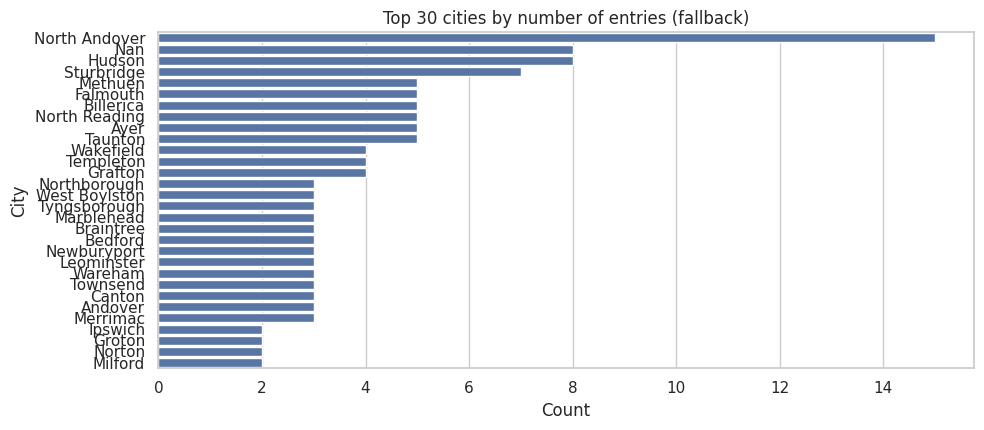

In [ ]:

# Heatmap plotting: if geocoded coords exist, plot hexbin/kde; otherwise fallback.

def plot_city_heatmap(df, city_coords=None, figsize=(10,8), save_path=None):
    plt.figure(figsize=figsize)
    if city_coords is not None and 'lat' in city_coords.columns and city_coords['lat'].notna().sum() > 3:
        # Merge coords with counts
        counts = df.groupby('city_for_geo').size().reset_index(name='count')
        merged = counts.merge(city_coords, on='city_for_geo', how='left').dropna(subset=['lat','lon'])
        if merged.empty:
            print('No merged geocoded points available; falling back.')
        else:
            x = merged['lon'].astype(float)
            y = merged['lat'].astype(float)
            c = merged['count'].astype(float)
            # scatter with size
            plt.scatter(x, y, s=(c / c.max()) * 500 + 20, alpha=0.6)
            for _, r in merged.iterrows():
                plt.text(r['lon'], r['lat'], r['city_for_geo'], fontsize=8, alpha=0.7)
            plt.title('City-level counts (geocoded scatter, size ~ count)')
            plt.xlabel('Longitude'); plt.ylabel('Latitude')
            if save_path: plt.savefig(save_path, bbox_inches='tight')
            plt.show()
            return
    # Fallback: bar chart + jittered scatter for city counts
    counts = df['city_for_geo'].value_counts().reset_index()
    counts.columns = ['city', 'count']
    top = counts.head(30)
    plt.subplot(2,1,1)
    sns.barplot(data=top, y='city', x='count')
    plt.title('Top 30 cities by number of entries (fallback)')
    plt.xlabel('Count'); plt.ylabel('City')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_city_heatmap(df, city_coords=None)


## Age Restricted vs Bedroom Size

We will show a boxplot of bedrooms grouped by age restriction, and a countplot showing distribution of bedroom counts per age group.

Using bedrooms column: Bedrooms


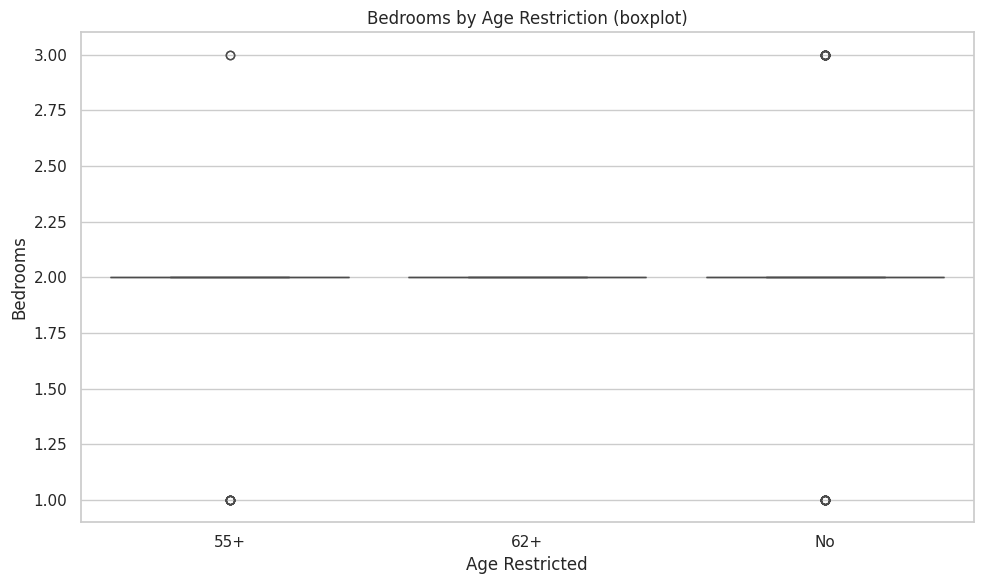

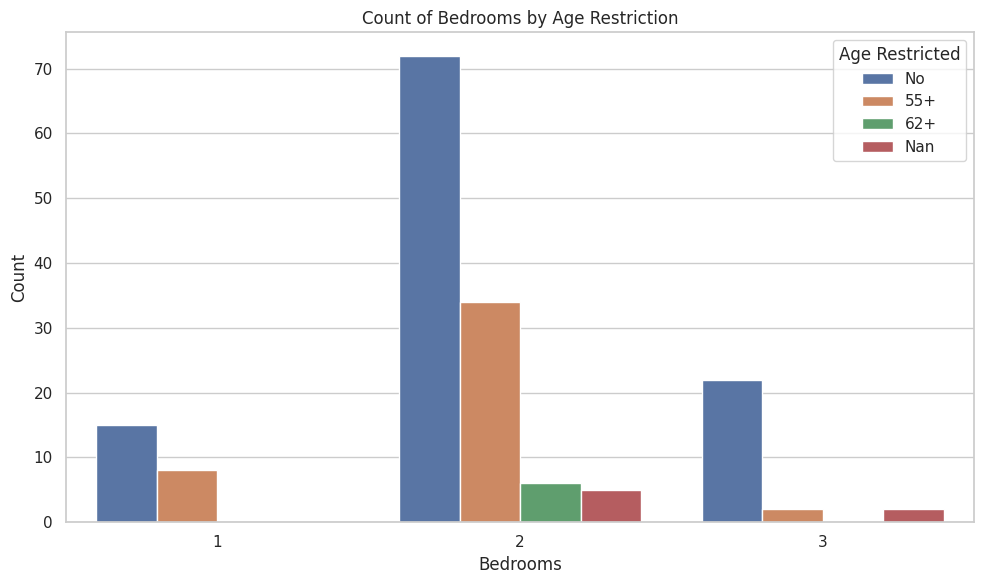

In [ ]:

# Prepare Bedrooms column as numeric
bed_col_candidates = [c for c in df.columns if 'bed' in c.lower()]
bed_col = bed_col_candidates[0] if bed_col_candidates else None
print('Using bedrooms column:', bed_col)
df['bedrooms_num'] = pd.to_numeric(df[bed_col], errors='coerce')

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='age_restricted', y='bedrooms_num', order=['55+','62+','No'])
plt.title('Bedrooms by Age Restriction (boxplot)')
plt.xlabel('Age Restricted'); plt.ylabel('Bedrooms')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='bedrooms_num', hue='age_restricted', order=sorted(df['bedrooms_num'].dropna().unique()))
plt.title('Count of Bedrooms by Age Restriction')
plt.xlabel('Bedrooms'); plt.ylabel('Count')
plt.legend(title='Age Restricted')
plt.tight_layout()
plt.show()


## Age Restricted vs Documentation Type

Grouped bar chart for counts of `Full/Lite` documentation type across age restriction categories.

Using documentation column: Full/Lite Documentation


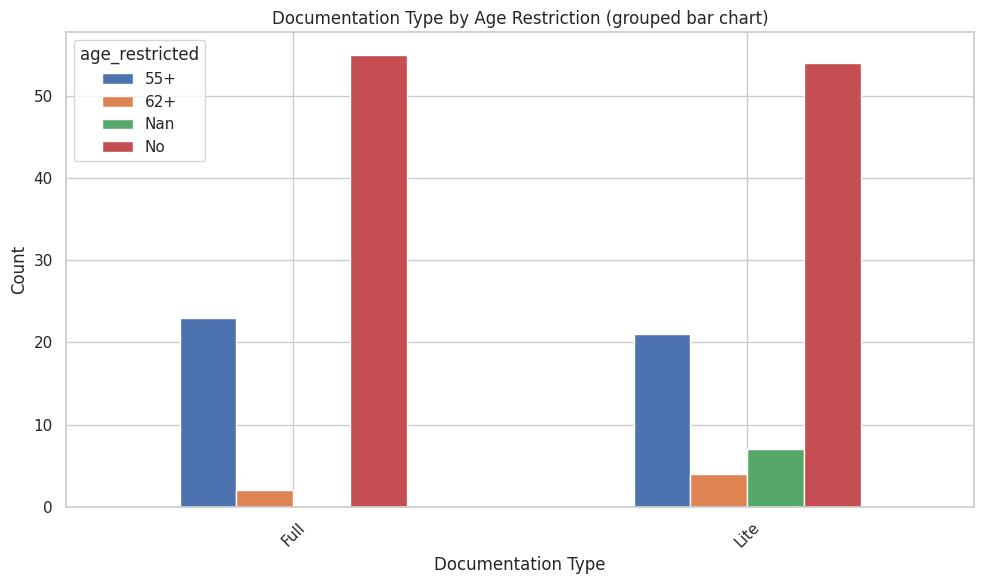

In [ ]:

# Find documentation column
doc_col_candidates = [c for c in df.columns if 'full' in c.lower() or 'lite' in c.lower() or 'documentation' in c.lower()]
doc_col = doc_col_candidates[0] if doc_col_candidates else None
print('Using documentation column:', doc_col)
df['doc_type'] = df[doc_col].astype(str).str.title()

doc_counts = (df.groupby(['age_restricted','doc_type']).size().reset_index(name='count'))
pivot = doc_counts.pivot(index='doc_type', columns='age_restricted', values='count').fillna(0)
pivot.plot(kind='bar', figsize=(10,6))
plt.title('Documentation Type by Age Restriction (grouped bar chart)')
plt.xlabel('Documentation Type'); plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Summary & Next Steps

- The notebook standardizes age restriction categories and visualizes relationships requested.
- Geocoding is included but optional — run the geocoding cell if you have internet. Results are cached to `city_coords_cache.csv`.
- You can tweak plot aesthetics, change the geocoding region (e.g., expand beyond MA), or increase top-N cities in the fallback bar chart.

If you'd like, I can also generate a fully-run HTML/PDF export of this notebook here (requires running the notebook cells).

/tmp/ipython-input-2860493068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 38.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 55.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 43.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 58.7% of the points

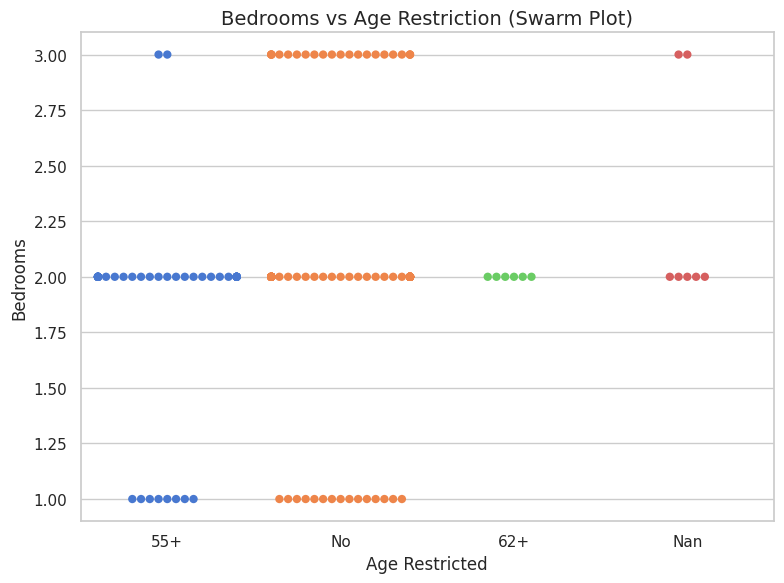

In [ ]:
plt.figure(figsize=(8,6))
sns.swarmplot(
    data=df,
    x='age_restricted',
    y='bedrooms_num',
    palette='muted',
    size=6
)
plt.title('Bedrooms vs Age Restriction (Swarm Plot)', fontsize=14)
plt.xlabel('Age Restricted')
plt.ylabel('Bedrooms')
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------
# Geocode unique cities (with caching)
# ---------------------------------------------------
# Requires internet access when you run this cell.
# Writes cached results to /mnt/data/city_geocode_cache.csv

import os
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster

cache_path = '/mnt/data/city_geocode_cache.csv'

def geocode_cities(df_cities, city_col='city', cache_path=cache_path):
    import time
    from geopy.geocoders import Nominatim
    from geopy.extra.rate_limiter import RateLimiter

    # Load cache if present
    if os.path.exists(cache_path):
        cache = pd.read_csv(cache_path)
    else:
        cache = pd.DataFrame(columns=[city_col, 'lat', 'lon', 'raw_address'])

    # Cities needing geocoding
    cities_to_code = [c for c in df_cities[city_col].unique() if c not in cache[city_col].values]
    print('Cities to geocode:', len(cities_to_code))

    if cities_to_code:
        geolocator = Nominatim(user_agent='eda_age_restricted_notebook')
        geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, max_retries=2)
        rows = []
        for c in cities_to_code:
            try:
                query = f"{c}, MA, USA"  # Assuming Massachusetts
                loc = geocode(query)
                if loc:
                    rows.append({city_col: c, 'lat': loc.latitude, 'lon': loc.longitude, 'raw_address': loc.address})
                else:
                    rows.append({city_col: c, 'lat': np.nan, 'lon': np.nan, 'raw_address': ''})
            except Exception as e:
                print('Geocode failure for', c, e)
                rows.append({city_col: c, 'lat': np.nan, 'lon': np.nan, 'raw_address': ''})
            time.sleep(1)  # polite pause

        if rows:
            new_df = pd.DataFrame(rows)
            cache = pd.concat([cache, new_df], ignore_index=True, sort=False)
            cache.to_csv(cache_path, index=False)
            print('Cache updated at', cache_path)

    return cache

print('To geocode, run: geocoded = geocode_cities(city_agg)')


# ---------------------------------------------------
# Create City Aggregation and Heatmap
# ---------------------------------------------------

def create_age_restricted_heatmap(df, city_col='city', age_col='age_restricted',
                                  cache_path=cache_path,
                                  map_filename='/mnt/data/age_restricted_heatmap.html'):
    """
    Creates an interactive Folium heatmap showing density of age-restricted properties (55+, 62+).
    """
    # Aggregate counts per city by age restriction
    agg = (df.groupby([city_col, age_col])
             .size()
             .reset_index(name='count'))

    # Pivot to wide form: one row per city
    city_agg = agg.pivot(index=city_col, columns=age_col, values='count').fillna(0).reset_index()
    city_agg['total'] = city_agg.sum(axis=1)
    city_agg['count_55plus'] = city_agg.get('55+', 0) + city_agg.get('62+', 0)
    city_agg['pct_55plus'] = city_agg['count_55plus'] / city_agg['total']

    # Merge with cached or newly created geocode data
    if os.path.exists(cache_path):
        geocoded = pd.read_csv(cache_path)
    else:
        geocoded = geocode_cities(city_agg, city_col=city_col, cache_path=cache_path)

    merged = city_agg.merge(geocoded, on=city_col, how='left').dropna(subset=['lat', 'lon'])
    if merged.empty:
        print('No valid geocoded points available. Run geocoding first.')
        return None

    # Create Folium map centered on mean location
    center = [merged['lat'].mean(), merged['lon'].mean()]
    m = folium.Map(location=center, zoom_start=8, tiles='CartoDB positron')

    # Add heatmap layer (weighted by % of age restricted)
    heat_data = [[row['lat'], row['lon'], row['pct_55plus'] * 100] for _, row in merged.iterrows()]
    HeatMap(heat_data, radius=15, blur=25, max_zoom=10, name='Age Restricted Heatmap').add_to(m)

    # Add optional clustered markers with info popups
    marker_cluster = MarkerCluster(name='City Markers').add_to(m)
    for _, row in merged.iterrows():
        popup_html = (f"<b>{row[city_col]}</b><br>"
                      f"Total: {int(row['total'])}<br>"
                      f"55+/62+: {int(row['count_55plus'])}<br>"
                      f"Pct 55+: {row['pct_55plus']:.2%}")
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=popup_html,
            icon=folium.Icon(color='blue', icon='home')
        ).add_to(marker_cluster)

    folium.LayerControl().add_to(m)
    m.save(map_filename)
    print(f"✅ Saved heatmap to {map_filename}")
    return m


# Example usage (after geocoding):
# geocoded = geocode_cities(df[['city']].drop_duplicates())
# create_age_restricted_heatmap(df, city_col='city', age_col='age_restricted')


To geocode, run: geocoded = geocode_cities(city_agg)


In [ ]:
geocoded = geocode_cities(df[['city']].drop_duplicates())
create_age_restricted_heatmap(df, city_col='city', age_col='age_restricted')


Cities to geocode: 59


/tmp/ipython-input-3507654047.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cache = pd.concat([cache, new_df], ignore_index=True, sort=False)


OSError: Cannot save file into a non-existent directory: '/mnt/data'